<a href="https://colab.research.google.com/github/nayzila/Tugas-Deep-Learning/blob/main/Tugas%20Deep%20Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import time
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader

In [2]:
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device yang digunakan: {device}")

Device yang digunakan: cuda


In [3]:
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 15

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

In [5]:
trainset = torchvision.datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

testset = torchvision.datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

classes = ("T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
           "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot")

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.74MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 29.3MB/s]


In [6]:
class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = torch.flatten(x, 1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [7]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual
        out = self.relu(out)
        return out

class MiniResNet(nn.Module):
    def __init__(self):
        super(MiniResNet, self).__init__()
        self.prep = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.res1 = ResidualBlock(64)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.transition = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.res2 = ResidualBlock(128)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, 10)

    def forward(self, x):
        x = self.prep(x)
        x = self.res1(x)
        x = self.pool1(x)
        x = self.transition(x)
        x = self.res2(x)
        x = self.pool2(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

--- Melatih Model A (Custom CNN) ---
[Model A] Epoch [01/15] | Train Loss: 0.3644 | Train Acc: 86.79% | Val Loss: 0.2897 | Val Acc: 89.26%
[Model A] Epoch [02/15] | Train Loss: 0.2425 | Train Acc: 91.09% | Val Loss: 0.2600 | Val Acc: 90.90%
[Model A] Epoch [03/15] | Train Loss: 0.2015 | Train Acc: 92.62% | Val Loss: 0.2806 | Val Acc: 89.81%
[Model A] Epoch [04/15] | Train Loss: 0.1717 | Train Acc: 93.77% | Val Loss: 0.2411 | Val Acc: 90.84%
[Model A] Epoch [05/15] | Train Loss: 0.1511 | Train Acc: 94.38% | Val Loss: 0.2302 | Val Acc: 92.01%
[Model A] Epoch [06/15] | Train Loss: 0.1300 | Train Acc: 95.14% | Val Loss: 0.2303 | Val Acc: 92.15%
[Model A] Epoch [07/15] | Train Loss: 0.1085 | Train Acc: 95.93% | Val Loss: 0.2505 | Val Acc: 92.61%
[Model A] Epoch [08/15] | Train Loss: 0.0928 | Train Acc: 96.51% | Val Loss: 0.2790 | Val Acc: 91.82%
[Model A] Epoch [09/15] | Train Loss: 0.0789 | Train Acc: 97.05% | Val Loss: 0.2879 | Val Acc: 92.12%
[Model A] Epoch [10/15] | Train Loss: 0.0671 

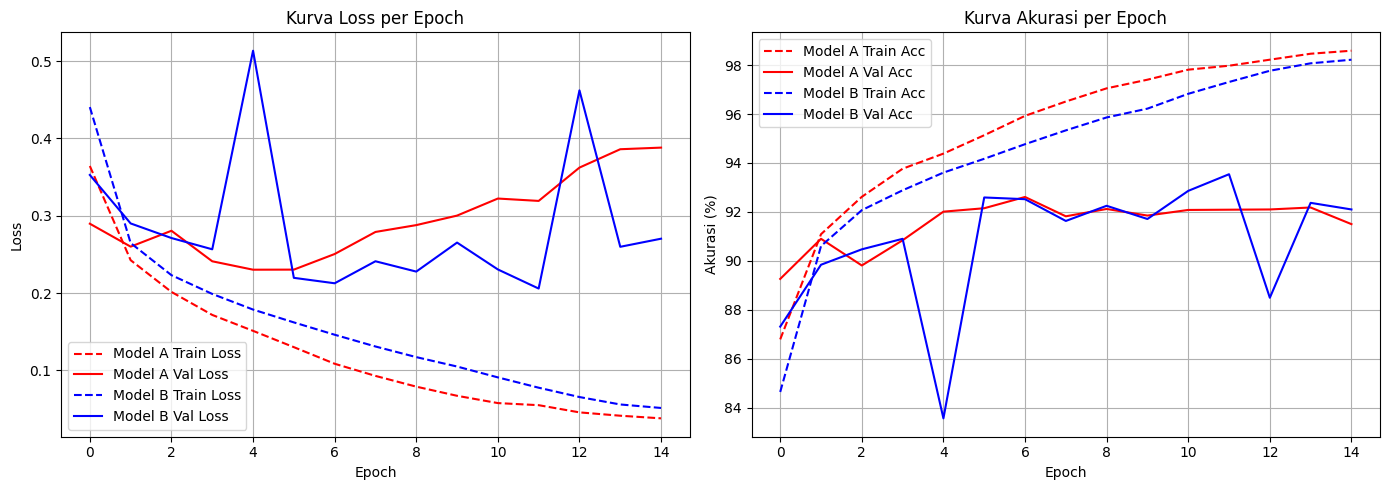

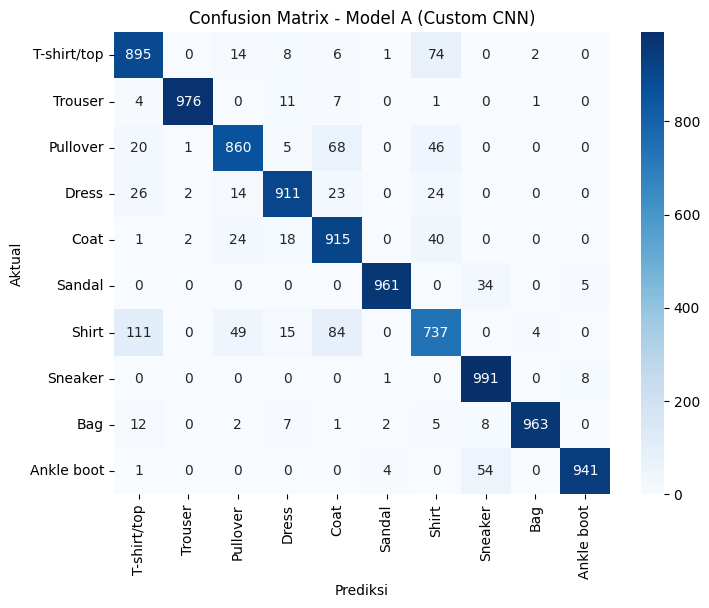

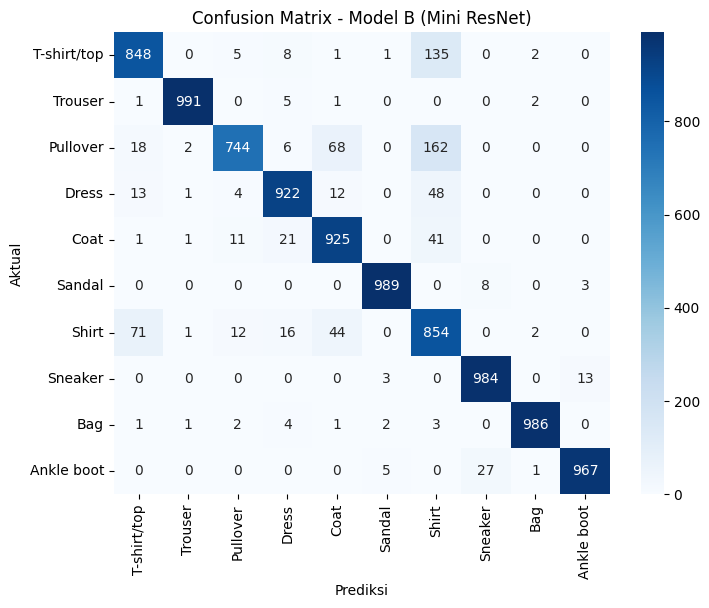

In [9]:
def train_and_evaluate(model, model_name):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "training_time": 0}
    start_time = time.time()

    for epoch in range(EPOCHS):
        # Training Phase
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(trainset)
        train_acc = 100.0 * correct / total

        # Validation/Testing Phase
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss = val_loss / len(testset)
        val_acc = 100.0 * val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"[{model_name}] Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    history["training_time"] = time.time() - start_time
    return history

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# 1. Jalankan Pelatihan
print("--- Melatih Model A (Custom CNN) ---")
model_a = CustomCNN()
history_a = train_and_evaluate(model_a, "Model A")

print("\n--- Melatih Model B (Mini ResNet) ---")
model_b = MiniResNet()
history_b = train_and_evaluate(model_b, "Model B")

# 2. Ringkasan Parameter, Waktu Training, dan Akurasi Akhir
print("\n" + "="*70)
print(f"{'Model':<20} | {'Total Parameter':<18} | {'Waktu (detik)':<15} | {'Test Acc (%)':<10}")
print("="*70)
print(f"{'Model A':<20} | {count_parameters(model_a):<18,} | {history_a['training_time']:<15.2f} | {history_a['val_acc'][-1]:<10.2f}")
print(f"{'Model B':<20} | {count_parameters(model_b):<18,} | {history_b['training_time']:<15.2f} | {history_b['val_acc'][-1]:<10.2f}")
print("="*70 + "\n")

# 3. Plot Kurva Loss dan Akurasi
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss
axs[0].plot(history_a["train_loss"], "r--", label="Model A Train Loss")
axs[0].plot(history_a["val_loss"], "r-", label="Model A Val Loss")
axs[0].plot(history_b["train_loss"], "b--", label="Model B Train Loss")
axs[0].plot(history_b["val_loss"], "b-", label="Model B Val Loss")
axs[0].set_title("Kurva Loss per Epoch")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].legend()
axs[0].grid(True)

# Plot Accuracy
axs[1].plot(history_a["train_acc"], "r--", label="Model A Train Acc")
axs[1].plot(history_a["val_acc"], "r-", label="Model A Val Acc")
axs[1].plot(history_b["train_acc"], "b--", label="Model B Train Acc")
axs[1].plot(history_b["val_acc"], "b-", label="Model B Val Acc")
axs[1].set_title("Kurva Akurasi per Epoch")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Akurasi (%)")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

# 4. Confusion Matrix
def plot_confusion_matrix(model, model_name):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Prediksi")
    plt.ylabel("Aktual")
    plt.show()

plot_confusion_matrix(model_a, "Model A (Custom CNN)")
plot_confusion_matrix(model_b, "Model B (Mini ResNet)")